# RNN Online Learning

**Train a GRU network on the copying task using D-RTRL**

This quickstart tutorial demonstrates how to train a Gated Recurrent Unit (GRU) network using online learning with `braintrace`. We will:

1. Define the **copying task**, a standard benchmark for testing sequential memory in RNNs.
2. Build a GRU model using `braintrace.nn` components.
3. Train the model with **D-RTRL** (Diagonal Real-Time Recurrent Learning), an online learning algorithm that computes approximate gradients without storing the full computation graph.
4. Compare the online learning approach with standard **Backpropagation Through Time (BPTT)**.

Online learning is especially useful when:
- Memory is limited and storing the full unrolled computation graph is prohibitive.
- You need to update parameters on-the-fly as data arrives.
- You want biologically plausible learning rules for recurrent networks.

## 1. Setup

First, we import the required packages.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
import brainstate
import braintools
import braintrace
import matplotlib.pyplot as plt

brainstate.random.seed(17)

## 2. The Copying Task

The copying task is a classic benchmark for evaluating whether an RNN can memorize and recall information over a delay period.

**How it works:**

1. The model receives a sequence of 10 random digits (values 1-8) encoded as one-hot vectors.
2. This is followed by a delay period filled with zeros (the "wait" phase).
3. A special trigger symbol (value 9) signals the model to reproduce the original 10 digits.

```
Input:    [3 7 1 5 2 8 4 6 1 3] [0 0 ... 0 0] [9 9 9 9 9 9 9 9 9 9]
                 memorize          wait/delay         recall trigger

Target:   [3 7 1 5 2 8 4 6 1 3]
```

The longer the delay (`time_lag`), the harder the task. The model must retain information in its hidden state across the entire delay period.

In [2]:
def make_copy_batches(n_epochs=200, time_lag=20, batch_size=32):
    """Create all fixed-seed copying batches without a Python iterator."""
    sequence_length = time_lag + 20
    digits = brainstate.random.randint(
        1, 9, size=(n_epochs, batch_size, 10)
    )
    symbol_ids = jnp.zeros(
        (n_epochs, batch_size, sequence_length), dtype=jnp.int32
    )
    symbol_ids = symbol_ids.at[..., :10].set(digits)
    symbol_ids = symbol_ids.at[..., -10:].set(9)
    inputs = jax.nn.one_hot(symbol_ids, 10, dtype=jnp.float32)
    inputs = jnp.transpose(inputs, (0, 2, 1, 3))
    targets = jnp.transpose(digits, (0, 2, 1))
    return inputs, targets

## 3. Model Definition

We define a GRU network using `braintrace.nn.GRUCell` for the recurrent layer and `braintrace.nn.Linear` for the output layer. These modules are designed to work with `braintrace`'s online learning algorithms -- they expose the internal structure needed for eligibility trace computation.

In [3]:
class GRUNet(brainstate.nn.Module):
    """A multi-layer GRU network with a linear readout.

    Args:
        n_in: Input feature dimension.
        n_rec: Hidden state dimension.
        n_out: Output dimension.
        n_layer: Number of stacked GRU layers.
    """

    def __init__(self, n_in, n_rec, n_out, n_layer=1):
        super().__init__()
        layers = []
        for _ in range(n_layer):
            layers.append(braintrace.nn.GRUCell(n_in, n_rec))
            n_in = n_rec
        self.rnn = brainstate.nn.Sequential(*layers)
        self.readout = braintrace.nn.Linear(n_rec, n_out)

    def update(self, x):
        return self.readout(self.rnn(x))

## 4. Online Training with D-RTRL

D-RTRL (Diagonal Real-Time Recurrent Learning) is an online learning algorithm
provided by `braintrace`. Unlike BPTT, which requires storing the entire
computation graph across all time steps, D-RTRL computes approximate gradients
incrementally using **eligibility traces**. It is not generally
gradient-equivalent to BPTT outside the assumptions of its diagonal Jacobian
approximation.

The key steps in the online training loop are:

1. **Map once**: Create `brainstate.nn.Map(model, init_map_size=B)` and call
   `mapped_model.init_all_states()`.
2. **Compile directly**: Construct `braintrace.D_RTRL(mapped_model)` and compile
   from one complete batched time step.
3. **Warm up**: Use `learner.etrace_evolve(...)` to advance hidden states and
   eligibility traces without computing a loss gradient.
4. **Learn**: Use `learner.etrace_grad(..., step_fn=step_loss)` to accumulate
   online gradients, then update the parameters.

An already mapped model must not be passed to
`braintrace.compile(..., vmap=True)`, because that would apply a second mapping
layer.

In [4]:
def train_online(input_batches, target_batches, time_lag=20, lr=2e-3):
    """Train one GRU with D-RTRL over precomputed copying batches."""
    brainstate.random.seed(21)
    model = GRUNet(10, 64, 10)
    batch_size = input_batches.shape[2]

    mapped_model = brainstate.nn.Map(model, init_map_size=batch_size)
    mapped_model.init_all_states()
    learner = braintrace.D_RTRL(mapped_model)
    learner.compile_graph(input_batches[0])

    opt = braintools.optim.Adam(lr)
    opt.register_trainable_weights(learner.param_states)

    @brainstate.transform.jit
    def train_step(inputs, targets):
        brainstate.nn.reset_all_states(mapped_model)
        learner.reset_state()

        # The loss for ONE step. `etrace_grad` owns the loop; this owns the
        # model call, so multi-head models and regularizers need no special
        # support.
        def step_loss(inp, tar):
            out = learner(inp)
            return braintools.metric.softmax_cross_entropy_with_integer_labels(out, tar).mean()

        # Warm-up: drive the model and its eligibility traces forward without
        # computing a gradient, so the recall period starts from a settled state.
        n_sim = time_lag + 10
        learner.etrace_evolve(inputs[:n_sim])

        # Learning phase: one call slices the sequence, differentiates each
        # step's loss online, and accumulates the per-step gradients.
        # `reduction='sum'` keeps the accumulated scale this example's learning
        # rate was tuned at.
        grads, losses = learner.etrace_grad(
            inputs[n_sim:], targets, step_fn=step_loss,
            reduction='sum', return_value=True,
        )
        opt.update(grads)
        return losses.mean()

    return brainstate.transform.for_loop(
        train_step, input_batches, target_batches
    )

## 5. BPTT Baseline (for Comparison)

To appreciate the advantages of online learning, we also implement a standard BPTT trainer. BPTT unrolls the full computation graph across all time steps, computes the loss, and backpropagates through the entire sequence. This requires storing all intermediate activations, resulting in memory usage that scales linearly with sequence length.

In [5]:
def train_bptt(input_batches, target_batches, time_lag=20, lr=2e-3):
    """Train a matched GRU with full-sequence BPTT."""
    brainstate.random.seed(21)
    model = GRUNet(10, 64, 10)
    opt = braintools.optim.Adam(lr)
    weights = model.states().subset(brainstate.ParamState)
    opt.register_trainable_weights(weights)

    @brainstate.transform.jit
    def train_step(inputs, targets):
        mapped_model = brainstate.nn.Map(
            model, init_map_size=inputs.shape[1]
        )
        mapped_model.init_all_states()

        def run_step(inp, tar):
            out = mapped_model(inp)
            loss = braintools.metric.softmax_cross_entropy_with_integer_labels(out, tar).mean()
            return out, loss

        def bptt_forward():
            n_sim = time_lag + 10
            brainstate.transform.for_loop(mapped_model, inputs[:n_sim])
            outs, losses = brainstate.transform.for_loop(run_step, inputs[n_sim:], targets)
            return losses.mean(), outs

        grads, loss, outs = brainstate.transform.grad(
            bptt_forward, weights, has_aux=True, return_value=True
        )()
        opt.update(grads)
        return loss

    return brainstate.transform.for_loop(
        train_step, input_batches, target_batches
    )

## 6. Run Training

Train the online (D-RTRL) and offline (BPTT) models on the same 200 fixed-seed batches. A 20-step delay preserves the temporal credit-assignment problem while the longer run makes the convergence comparison easier to inspect.

In [6]:
brainstate.random.seed(101)
copy_inputs, copy_targets = make_copy_batches(
    n_epochs=200, time_lag=20, batch_size=32
)
online_losses = train_online(copy_inputs, copy_targets)
print(f"Step 0, Loss: {float(online_losses[0]):.4f}")
print(f"Step 100, Loss: {float(online_losses[100]):.4f}")
print(f"Step 199, Loss: {float(online_losses[-1]):.4f}")

Step 0, Loss: 2.2856
Step 100, Loss: 2.0735
Step 199, Loss: 2.0434


In [7]:
bptt_losses = train_bptt(copy_inputs, copy_targets)
print(f"Step 0, Loss: {float(bptt_losses[0]):.4f}")
print(f"Step 100, Loss: {float(bptt_losses[100]):.4f}")
print(f"Step 199, Loss: {float(bptt_losses[-1]):.4f}")

Step 0, Loss: 2.2856
Step 100, Loss: 2.0601
Step 199, Loss: 2.0104


## 7. Visualization

Plot the training loss curves to compare online learning (D-RTRL) with BPTT.

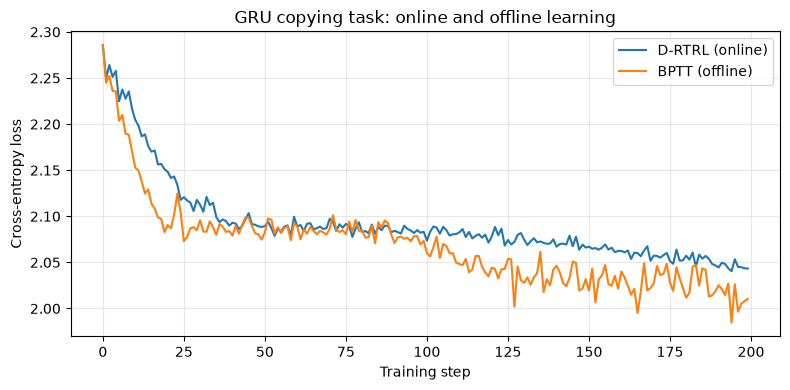

In [8]:
with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(online_losses, label="D-RTRL (online)")
    ax.plot(bptt_losses, label="BPTT (offline)")
    ax.set(xlabel="Training step", ylabel="Cross-entropy loss")
    ax.set_title("GRU copying task: online and offline learning")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
plt.show()

## 8. Summary

In this tutorial, we demonstrated online learning of a GRU on the copying task.

**Key takeaways:**

- **D-RTRL** provides approximate online gradients with `O(B * theta)`
  complexity, where `B` is the batch size and `theta` is the number of
  parameters. Unlike BPTT, it does not store the full unrolled graph.
- Batched online learning creates one `brainstate.nn.Map`, initializes it, and
  passes it directly to `braintrace.D_RTRL` before `compile_graph` is called on
  a complete batched time step.
- Do not pass an already mapped model to `compile(..., vmap=True)`.
- Use `learner.etrace_evolve` for gradient-free prefixes and
  `learner.etrace_grad` for sequence objectives.

For more details, see:
- [Key Concepts](../quickstart/concepts.ipynb) for the theoretical background.
- [SNN Online Learning](./snn_online_learning.ipynb) for spiking networks.